# Comparing Data Sets.
____

In [1]:
from pathlib import Path
from microlive.imports import *
from microlive import microscopy as mi
current_dir = Path().resolve()
parent_dir = current_dir.parents[1]
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import sys
repo_root = Path().resolve().parents[1]  # Go up to cof_paper/
sys.path.insert(0, str(repo_root))
import utilities as ld
importlib.reload(ld)


<module 'utilities' from 'C:\\Users\\searsrh\\OneDrive - The University of Colorado Denver\\Desktop\\cof_paper\\utilities\\__init__.py'>

## Loading data and strings for subclassification
___

In [2]:
# Loading data
        #RMS External Drive Location:    'E:/Co-translational folding (CoF) paper/CoF Analysis/Fig S4_4xSlow XBP1u coTFT minitrack analysis'
        #Ning Zhao OneDrive Location:    '...General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/co-translational folding paper/Fig S4/S4G-J_4xSlow XBP1u CoF analysis/4xSlow XBP1u CoF analysis'

dataframes_dir = Path('E:/Co-translational folding (CoF) paper/CoF Analysis/Fig S4_4xSlow XBP1u coTFT minitrack analysis')


# Average Folder Substrings

list_folder_substring_to_avoid = None


save_dir = current_dir.joinpath('results_Fig S4G-J_CoF')
save_dir.mkdir(parents=True, exist_ok=True)

# Individual day Folder Substrings
plot_individual_days = False     # Set to False to skip plotting individual experiment days and plot the overall average.

list_folder_substrings, list_names = ld.get_folder_substrings_and_names(
    dataframes_dir, 
    process_individual_days=plot_individual_days,
)
print(list_folder_substrings) #list for variant number in graphs below
print(list_names)


Found 3 plasmids in 78 folders
  pRS049: 2 experiment(s)
  pRS032: 2 experiment(s)
  pRS039: 2 experiment(s)
['pRS032', 'pRS039', 'pRS049']
['4GFPuv-2mCh', '4GFPuv-2mCh-Xbp1', 'Xbp1-4GFPuv-2mCh']


## Loading the data
____

In [3]:
data_dict = ld.aggregate_folder_data(dataframes_dir,list_folder_substrings,
            list_folder_substring_to_avoid,list_folder_substring_second_condition=None,
            show_file_names=True, verbose= False)

Loaded results_20250827 pRS032_012_JF646 6hr Tfx_Series001 (2 channels)
Loaded results_20250825 pRS032_012_JF646 4hr Tfx_Series001 (2 channels)
Loaded results_20250827 pRS032_012_JF646 6hr Tfx_Series002 (2 channels)
Loaded results_20250827 pRS032_012_JF646 6hr Tfx_Series003 (2 channels)
Loaded results_20250825 pRS032_012_JF646 4hr Tfx_Series003 (2 channels)
Loaded results_20250827 pRS032_012_JF646 6hr Tfx_Series004 (2 channels)
Loaded results_20250825 pRS032_012_JF646 4hr Tfx_Series004 (2 channels)
Loaded results_20250827 pRS032_012_JF646 6hr Tfx_Series005 (2 channels)
Loaded results_20250825 pRS032_012_JF646 4hr Tfx_Series005 (2 channels)
Loaded results_20250827 pRS032_012_JF646 6hr Tfx_Series006 (2 channels)
Loaded results_20250827 pRS032_012_JF646 6hr Tfx_Series007 (2 channels)
Loaded results_20250825 pRS032_012_JF646 4hr Tfx_Series007 (2 channels)
Loaded results_20250827 pRS032_012_JF646 6hr Tfx_Series008 (2 channels)
Loaded results_20250825 pRS032_012_JF646 4hr Tfx_Series008 (2 ch

## Plotting Configuration
___

In [4]:
# ── Plotting Configuration ─────────────────────────────────
PLOT_CONFIG = dict(
    figsize       = (4.5, 4),
    tick_size     = 12,
    swarm_color   = 'black',
    show_stats    = True,
    only_significant = True,
    max_percentile_significance = 99.5,
    cell_summary='median',  # each dot = np.nanmedian of all spots in that cell
)
SAVE_DIR = save_dir  # Defined in data config above; set to None to skip saving

 


## Plotting data
___

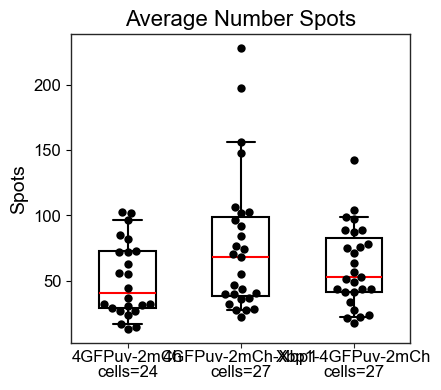

<Axes: title={'center': 'Average Number Spots'}, ylabel='Spots'>

In [5]:
# avg spots/frame in one cell. raw tracking rows divided by frame count.
ld.plot_swarm_plot(
    data_dict['average_number_spots'], list_names,
    y_label='Spots',
    title='Average Number Spots',
    #y_lim=(0, 300),
    plot_name='avg_spots',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


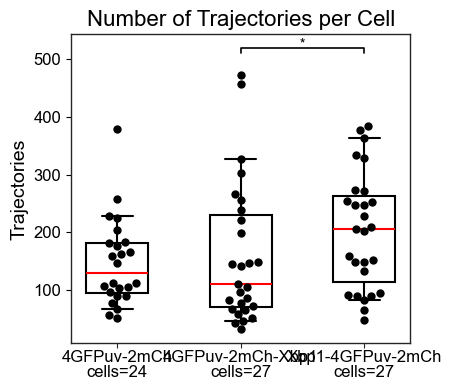

<Axes: title={'center': 'Number of Trajectories per Cell'}, ylabel='Trajectories'>

In [6]:
# unique trajectories in one cell. Trajectories >= 3 frames.
ld.plot_swarm_plot(
    data_dict['n_trajectories'], list_names,
    y_label='Trajectories',
    title='Number of Trajectories per Cell',
    y_lim=(0, 500),
    plot_name='n_trajectories',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


## Folding-colocalized

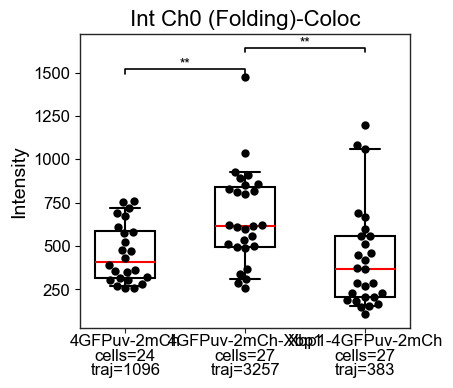

<Axes: title={'center': 'Int Ch0 (Folding)-Coloc'}, ylabel='Intensity'>

In [7]:
ld.plot_swarm_plot(
    data_dict['int_ch_0_coloc'], list_names,
    y_label='Intensity',
    title='Int Ch0 (Folding)-Coloc',
    y_lim=(-100, 2000),
    plot_name='int_ch0_coloc',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)

# Nascent Chain 

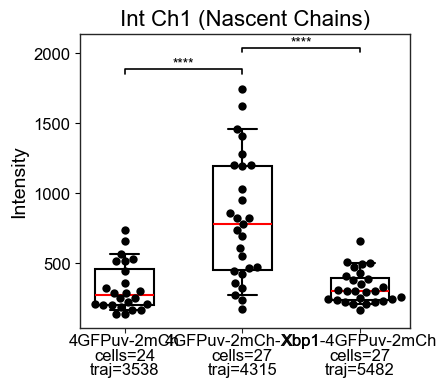

<Axes: title={'center': 'Int Ch1 (Nascent Chains)'}, ylabel='Intensity'>

In [8]:
ld.plot_swarm_plot(
    data_dict['int_ch_1'], list_names,
    y_label='Intensity',
    title='Int Ch1 (Nascent Chains)',
    y_lim=(0, 2200),
    plot_name='int_ch1',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


## Nascent chain-colocalized

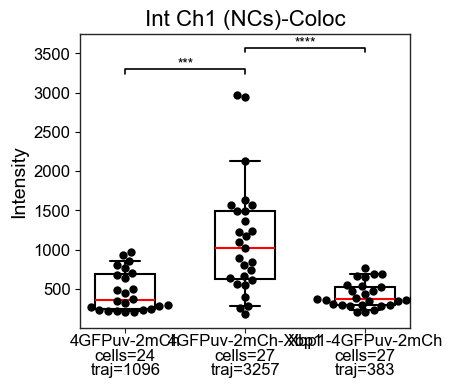

<Axes: title={'center': 'Int Ch1 (NCs)-Coloc'}, ylabel='Intensity'>

In [9]:
ld.plot_swarm_plot(
    data_dict['int_ch_1_coloc'], list_names,
    y_label='Intensity',
    title='Int Ch1 (NCs)-Coloc',
    y_lim=(0, 2500),
    plot_name='int_ch1_coloc',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)

## Nascent chain-not-colocalized

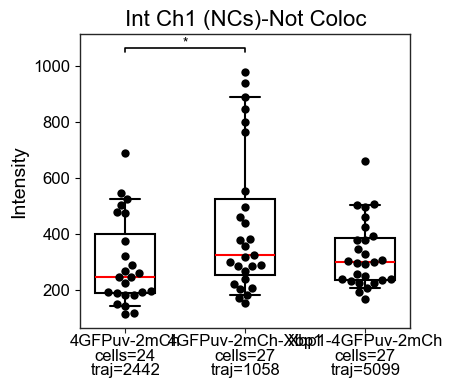

<Axes: title={'center': 'Int Ch1 (NCs)-Not Coloc'}, ylabel='Intensity'>

In [10]:
ld.plot_swarm_plot(
    data_dict['int_ch_1_not_coloc'], list_names,
    y_label='Intensity',
    title='Int Ch1 (NCs)-Not Coloc',
    y_lim=(0, 1500),
    plot_name='int_ch1_not_coloc',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)

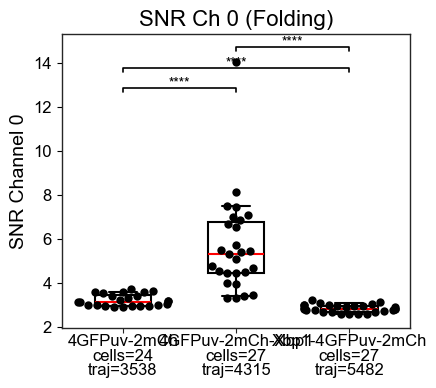

<Axes: title={'center': 'SNR Ch 0 (Folding)'}, ylabel='SNR Channel 0'>

In [11]:
ld.plot_swarm_plot(
    data_dict['snr_ch_0'], list_names,
    title='SNR Ch 0 (Folding)',
    y_label='SNR Channel 0',
    plot_name='snr_ch0',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


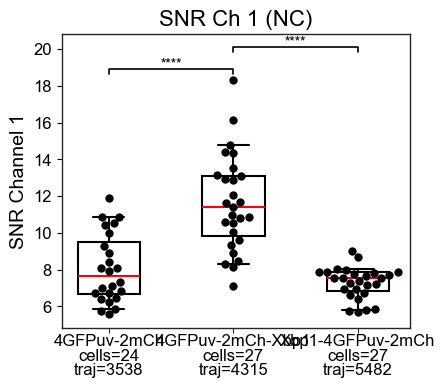

<Axes: title={'center': 'SNR Ch 1 (NC)'}, ylabel='SNR Channel 1'>

In [12]:
ld.plot_swarm_plot(
    data_dict['snr_ch_1'], list_names,
    title='SNR Ch 1 (NC)',
    y_label='SNR Channel 1',
    plot_name='snr_ch1',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


## Calculating Folding Efficiency using ML method

___

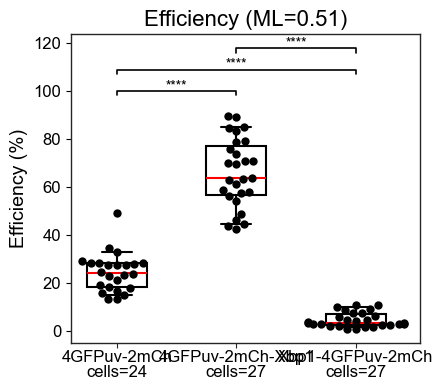

<Axes: title={'center': 'Efficiency (ML=0.51)'}, ylabel='Efficiency (%)'>

In [13]:
ld.plot_swarm_plot(
    data_dict['efficiency_ml'], list_names,
    y_label='Efficiency (%)',
    title='Efficiency (ML=0.51)',
    y_lim=(-10, 110),
    plot_name='efficiency_ml',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


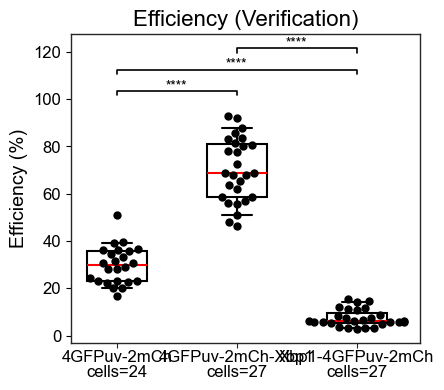

<Axes: title={'center': 'Efficiency (Verification)'}, ylabel='Efficiency (%)'>

In [14]:
ld.plot_swarm_plot(
    data_dict['efficiency_manual'], list_names,
    y_label='Efficiency (%)',
    title='Efficiency (Verification)',
    y_lim=(-10, 125),
    plot_name='efficiency_verification',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
    swarm_size=6,
)
